In [4]:
# %% 
import sys
from pathlib import Path
import random

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

# --- make sure the project root (the folder that contains `src/`) is on sys.path ---

# Notebook is in RECAP/src/, so repo root is one level up
REPO_ROOT = Path.cwd().parent   # /Users/aryananand/Documents/RECAP
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

# Now import from the `src` package
from src.common import (
    PROJECT_ROOT,
    get_device,
    set_seed,
    IDX2LABEL,
    to_numpy_image,
)
from src.dataset_tiles import TileBuildingDataset
from src.model_polygon_siamese import (
    SiameseTileBackbone,
    DamageHead,
    rasterize_polygon_mask,
    mask_pool_features,
)


In [5]:
# %%
# Basic config
DATA_ROOT = PROJECT_ROOT / "data" / "xBD Dataset"
MODEL_PATH = PROJECT_ROOT / "models" / "polygon_siamese_best.pt"
SPLIT = "test"          # use "test" split for unseen tiles
RESIZE = 512
SEED = 42

set_seed(SEED)
device = get_device(prefer_gpu=True)
print("Device:", device)

assert MODEL_PATH.exists(), f"Checkpoint not found: {MODEL_PATH}"

# Load checkpoint (allow full objects – you trust your own file)
ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)
cfg_train = ckpt.get("config", None)
print("Loaded checkpoint keys:", list(ckpt.keys()))
if cfg_train is not None:
    print("Checkpoint trained with config:", cfg_train)

# Build backbone + head
# Important: imagenet_weights=False here to avoid re-downloading; 
# weights are overwritten by ckpt anyway.
backbone = SiameseTileBackbone(imagenet_weights=False).to(device)

# Training used rich features: concat(v_pre, v_post, |diff|, diff) -> 4 * out_channels
head_in_dim = 4 * backbone.out_channels
head = DamageHead(in_dim=head_in_dim, n_classes=4).to(device)

backbone.load_state_dict(ckpt["backbone"])
head.load_state_dict(ckpt["head"])

backbone.eval()
head.eval()

print("Model loaded and ready.")


Device: cpu
Loaded checkpoint keys: ['backbone', 'head', 'config']
Checkpoint trained with config: {'DATA_ROOT': 'C:\\Users\\yatin\\Desktop\\RECAP\\data\\xBD Dataset', 'TRAIN_SPLIT': 'train', 'RESIZE': 512, 'EPOCHS': 30, 'LR': 0.0002, 'WEIGHT_DECAY': 0.0001, 'SAMPLES_PER_EPOCH_GPU': 80000, 'SAMPLES_PER_EPOCH_CPU': 30000, 'BATCH_BUILDINGS_GPU': 16, 'BATCH_BUILDINGS_CPU': 8, 'NUM_WORKERS_GPU': 4, 'NUM_WORKERS_CPU': 0, 'IMAGENET_BACKBONE': True, 'CLASS_WEIGHTS': [0.5, 1.2, 1.5, 1.5], 'ORD_LOSS_WEIGHT': 0.0, 'SEED': 42, 'SAVE_BEST_PATH': 'C:\\Users\\yatin\\Desktop\\RECAP\\models\\polygon_siamese_best.pt'}
[PolygonSiamese] Using ResNet-34 with random init (no pretrained weights).
Model loaded and ready.


In [6]:
# %%
# Build TileBuildingDataset on the test split
ds = TileBuildingDataset(
    root=str(DATA_ROOT),
    split=SPLIT,
    resize=RESIZE,
    limit_tiles=None,  # all test tiles
)

print(f"Test tiles available: {len(ds)}")


Test tiles available: 933


In [7]:
# %%
def make_change_features(v_pre: torch.Tensor, v_post: torch.Tensor) -> torch.Tensor:
    """
    Same as training:
      diff = v_post - v_pre
      abs_diff = |diff|
      feat = concat(v_pre, v_post, abs_diff, diff)
    Result shape: (4C,)
    """
    diff = v_post - v_pre
    abs_diff = torch.abs(diff)
    feat = torch.cat([v_pre, v_post, abs_diff, diff], dim=0)
    return feat


In [8]:
# %%
# Pick a random tile that actually has buildings
max_tries = 50
tile_idx = None

for _ in range(max_tries):
    idx = random.randint(0, len(ds) - 1)
    pre_t, post_t, polys_xy, labels_t, tile_id, orig_w, orig_h = ds[idx]
    if labels_t.numel() > 0:
        tile_idx = idx
        break

if tile_idx is None:
    raise RuntimeError("Could not find a tile with at least 1 building in test set.")

print(f"Using tile index: {tile_idx}, tile_id = {tile_id}")
print(f"Number of buildings in this tile: {labels_t.numel()}")

# Move tensors to device
pre_t = pre_t.to(device)   # shape (1,3,H,W)
post_t = post_t.to(device)
labels_t = labels_t.to(device)

# Forward through backbone
with torch.no_grad():
    F_pre = backbone(pre_t)[0]   # (C,Hf,Wf)
    F_post = backbone(post_t)[0]

C, Hf, Wf = F_pre.shape
print("Feature map shape:", (C, Hf, Wf))

feats = []
y_true_list = []

# orig_w, orig_h come from dataset as ints
ow = float(orig_w)
oh = float(orig_h)

for poly_xy, y in zip(polys_xy, labels_t):
    # Rasterize polygon mask at feature resolution
    mask = rasterize_polygon_mask(poly_xy, Hf, Wf, ow, oh, device)
    if mask.sum() < 1.0:
        continue

    v_pre = mask_pool_features(F_pre, mask)
    v_post = mask_pool_features(F_post, mask)
    feat = make_change_features(v_pre, v_post)
    feats.append(feat)
    y_true_list.append(int(y.item()))

if len(feats) == 0:
    raise RuntimeError("All polygons had empty masks for this tile; try re-running to pick another tile.")

X = torch.stack(feats, dim=0)  # (N_buildings, 4C)
y_true = np.array(y_true_list, dtype=np.int64)

with torch.no_grad():
    logits = head(X)
    probs = torch.softmax(logits, dim=1)
    confs, preds = probs.max(dim=1)

y_pred = preds.cpu().numpy().astype(int)
confs_np = confs.cpu().numpy().astype(float)

# Build a results table
rows = []
for i, (yt, yp, c) in enumerate(zip(y_true, y_pred, confs_np)):
    rows.append(
        {
            "building_idx": i,
            "true_label": IDX2LABEL[int(yt)],
            "pred_label": IDX2LABEL[int(yp)],
            "confidence": round(float(c), 4),
        }
    )

df_results = pd.DataFrame(rows)
df_results.head(10)


Using tile index: 654, tile_id = socal-fire_00000170_post_disaster
Number of buildings in this tile: 22
Feature map shape: (512, 16, 16)


,building_idx,true_label,pred_label,confidence
0,0,destroyed,destroyed,0.7885
1,1,destroyed,destroyed,0.9997
2,2,destroyed,destroyed,0.9997
3,3,no-damage,destroyed,0.5374
4,4,no-damage,destroyed,0.9319
5,5,no-damage,no-damage,0.4547
6,6,no-damage,destroyed,0.3826
7,7,destroyed,destroyed,0.5971
8,8,no-damage,no-damage,0.9511
9,9,no-damage,no-damage,0.9587


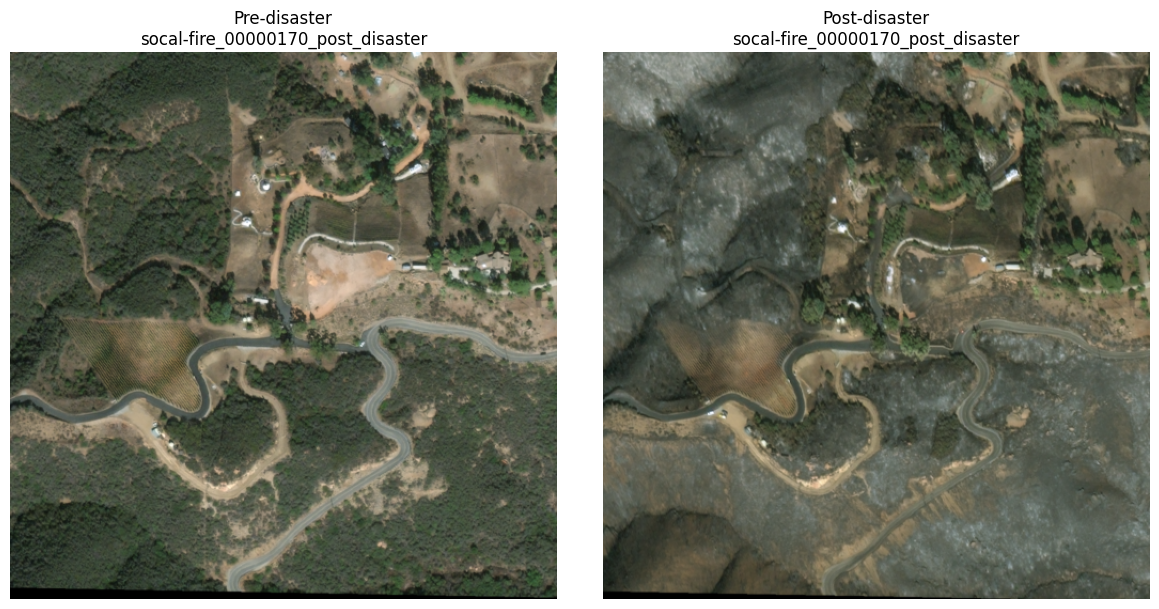

In [9]:
# %%
# Convert tensors (1,3,H,W) -> numpy images (H,W,3)
pre_rgb = to_numpy_image(pre_t[0].cpu())
post_rgb = to_numpy_image(post_t[0].cpu())

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(pre_rgb)
axs[0].set_title(f"Pre-disaster\n{tile_id}")
axs[0].axis("off")

axs[1].imshow(post_rgb)
axs[1].set_title(f"Post-disaster\n{tile_id}")
axs[1].axis("off")

plt.tight_layout()
plt.show()
